# Sweep analysis: deformation, directors, stress and reconstructed strain

Based on the current `postprocess.ipynb`. Set **OUTDIR** below to the run to inspect,
then run the cells in order. The current softer-material run is selected using its
absolute path so this notebook can run from this project folder. If placed beside
the simulation scripts, `OUTDIR = "output_04_softer"` also works.

Requires NumPy, Matplotlib, Pillow and IPython in the notebook kernel. No FEniCS
installation or new simulation is needed. The final cells write director and stress
GIFs into OUTDIR (replacing GIFs with the same names).

Snapshot comparisons use the nearest saved times to **0, 2.5, 5, 10**, with actual
times shown. Each field uses one color scale across the entire loaded run, including
the animations. These scales are per run, not shared automatically between runs.

Strain is dimensionless and reconstructed approximately from the saved
**CG1-interpolated displacement field**. It is constant within each triangle.
For thesis-quality quantitative output, strain should eventually be saved directly
from the **CG2 solution**, using an appropriate projection/output space. Differentiating
the CG1 interpolant loses within-element information from CG2. This notebook does
not modify `solver.py`.

In [1]:
import glob
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.colors import Normalize
from matplotlib.animation import FuncAnimation, PillowWriter

OUTDIR = "output"  # point this at whichever run's output dir you want to inspect
SNAP_DIR = os.path.join(OUTDIR, "snapshots")
DEFORM_SCALE = 1.0  # multiply displacement before warping the plotted mesh

# The mesh is dense enough that plotting one director glyph per node is
# unreadable. NBINS_X/NBINS_Y set a coarser grid that the director field is
# spatially averaged onto for display (see `binned_directors` below).
NBINS_X = 14
NBINS_Y = 34

TARGET_TIMES = np.array([0.0, 2.5, 5.0, 10.0])
STRAIN_TARGET_TIME = 2.5  # time for the four-component strain figure

In [2]:
snap_files = sorted(glob.glob(os.path.join(SNAP_DIR, "step_*.npz")))

if not snap_files:
    raise FileNotFoundError(f"No snapshots found in {SNAP_DIR}. Check OUTDIR.")

# Connectivity is stored only in the first snapshot. Coordinates are reference
# coordinates, and connectivity must index the same nodal ordering as coords/u.
with np.load(snap_files[0], allow_pickle=False) as first:
    connectivity = first["connectivity"].copy()
    coords_ref = np.asarray(first["coords"], dtype=float).copy()

if coords_ref.ndim != 2 or coords_ref.shape[1] != 2 or not np.isfinite(coords_ref).all():
    raise ValueError("Expected finite reference coordinates of shape (n_nodes, 2).")
if (connectivity.ndim != 2 or connectivity.shape[1] != 3
        or len(connectivity) == 0 or not np.issubdtype(connectivity.dtype, np.integer)):
    raise ValueError("Expected nonempty integer triangle connectivity of shape (n_cells, 3).")
if connectivity.min() < 0 or connectivity.max() >= len(coords_ref):
    raise ValueError("Connectivity contains out-of-range node indices.")

snapshots = []
fields = ["t", "coords", "u", "von_mises", "Qxx", "Qxy", "theta", "S"]
for filename in snap_files:
    with np.load(filename, allow_pickle=False) as data:
        snap = {key: data[key].copy() for key in fields}
    if np.asarray(snap["t"]).size != 1:
        raise ValueError(f"{filename}: expected a scalar time.")
    snap["t"] = float(np.asarray(snap["t"]).item())
    for key in fields:
        if not np.isfinite(snap[key]).all():
            raise ValueError(f"{filename}: non-finite {key} values.")
    if snap["coords"].shape != coords_ref.shape or not np.array_equal(snap["coords"], coords_ref):
        raise ValueError(f"{filename}: reference mesh coordinates changed.")
    if snap["u"].shape != coords_ref.shape:
        raise ValueError(f"{filename}: expected displacement shape {coords_ref.shape}.")
    for key in ["von_mises", "Qxx", "Qxy", "theta", "S"]:
        if snap[key].shape != (len(coords_ref),):
            raise ValueError(f"{filename}: {key} must have one value per node.")
    snapshots.append(snap)

# Sort by physical time, independently of filename ordering.
snapshots.sort(key=lambda snap: snap["t"])
times = np.array([snap["t"] for snap in snapshots])
if np.any(np.diff(times) == 0):
    warnings.warn("Duplicate saved times found; nearest-time selection uses the first match.")
print(f"Loaded {len(snapshots)} snapshots, t in [{times[0]:.6g}, {times[-1]:.6g}]")

Loaded 151 snapshots, t in [0, 15]


In [4]:
def deformed_coords(snap, scale=DEFORM_SCALE):
    return coords_ref + scale * snap["u"]


def triangulation(snap, scale=DEFORM_SCALE):
    xy = deformed_coords(snap, scale)
    return mtri.Triangulation(xy[:, 0], xy[:, 1], connectivity)


def binned_directors(snap, nbins_x=NBINS_X, nbins_y=NBINS_Y):
    """Coarse-grain the director field onto an nbins_x x nbins_y grid.

    Nematic directors are headless (theta and theta+pi are the same state),
    so they can't be averaged as angles directly -- averaging wraps around
    incorrectly near the +/-pi/2 branch cut. Averaging the Cartesian Q-tensor
    components (Qxx, Qxy) is the correct way to coarse-grain a nematic field:
    it's linear, so head-tail symmetry (Q(theta) == Q(theta+pi)) is baked in
    automatically, and the result is exactly what continuum nematic theory
    calls the coarse-grained order parameter.
    """
    xy = deformed_coords(snap)
    Qxx, Qxy = snap["Qxx"], snap["Qxy"]
    x, y = xy[:, 0], xy[:, 1]

    xedges = np.linspace(x.min(), x.max(), nbins_x + 1)
    yedges = np.linspace(y.min(), y.max(), nbins_y + 1)
    ix = np.clip(np.digitize(x, xedges) - 1, 0, nbins_x - 1)
    iy = np.clip(np.digitize(y, yedges) - 1, 0, nbins_y - 1)
    bin_id = ix * nbins_y + iy
    n_bins = nbins_x * nbins_y

    count = np.bincount(bin_id, minlength=n_bins)
    occupied = count > 0
    qxx_avg = np.bincount(bin_id, weights=Qxx, minlength=n_bins)[occupied] / count[occupied]
    qxy_avg = np.bincount(bin_id, weights=Qxy, minlength=n_bins)[occupied] / count[occupied]
    x_c = np.bincount(bin_id, weights=x, minlength=n_bins)[occupied] / count[occupied]
    y_c = np.bincount(bin_id, weights=y, minlength=n_bins)[occupied] / count[occupied]

    theta = 0.5 * np.arctan2(qxy_avg, qxx_avg)
    S = np.sqrt(qxx_avg**2 + qxy_avg**2)
    return x_c, y_c, theta, S


def director_segments(snap, length=None):
    """Line-segment endpoints for a headless director glyph, one per bin."""
    x_c, y_c, theta, S = binned_directors(snap)
    if length is None:
        # a reasonable glyph length relative to the bin spacing
        length = 0.4 * np.ptp(coords_ref[:, 1]) / NBINS_Y
    dx = length * S * np.cos(theta)
    dy = length * S * np.sin(theta)
    x0, y0 = x_c - dx, y_c - dy
    x1, y1 = x_c + dx, y_c + dy
    return x0, y0, x1, y1

## Small strain on the reference mesh

We reconstruct $\varepsilon=\tfrac12(\nabla u+\nabla u^T)$:
$\varepsilon_{xx}=\partial_x u_x$, $\varepsilon_{yy}=\partial_y u_y$,
$\varepsilon_{xy}=\tfrac12(\partial_y u_x+\partial_x u_y)$, and
$\gamma_{xy}=2\varepsilon_{xy}$. Positive normal strain denotes extension;
shear components are signed. These are small-strain measures, not finite-strain measures.

Derivatives use reference coordinates and the unscaled saved displacement.
`DEFORM_SCALE` changes only the displayed geometry. Flat triangle colors preserve
the piecewise-constant reconstruction; no artificial nodal smoothing is applied.
Degenerate or numerically singular reference triangles trigger a clear error.

In [5]:
def prepare_strain_geometry(coords, triangles):
    """Build local edge matrices; accept either triangle orientation."""
    points = coords[triangles]
    edges = points[:, 1:, :] - points[:, :1, :]
    det = edges[:, 0, 0] * edges[:, 1, 1] - edges[:, 0, 1] * edges[:, 1, 0]
    scale2 = np.max(np.sum(edges**2, axis=2), axis=1)
    bad = np.abs(det) <= 100 * np.finfo(float).eps * scale2
    if np.any(bad):
        raise ValueError(f"Degenerate/near-singular reference triangles: {np.flatnonzero(bad)[:10].tolist()}")
    return edges


strain_edges = prepare_strain_geometry(coords_ref, connectivity)


def element_strain(snap):
    """Approximate strain of the saved CG1 interpolant, one value per triangle.

    For thesis-quality quantitative output, eventually save strain directly
    from the CG2 solution. This reconstruction cannot recover CG2 gradients.
    """
    displacement = np.asarray(snap["u"], dtype=float)
    if displacement.shape != coords_ref.shape or not np.isfinite(displacement).all():
        raise ValueError("Displacement must be finite with shape (n_nodes, 2).")
    nodal = displacement[connectivity]
    differences = nodal[:, 1:, :] - nodal[:, :1, :]
    # edges @ gradient = displacement differences; subtracting the first
    # vertex avoids a poorly conditioned [1, x, y] solve at large offsets.
    gradient = np.linalg.solve(strain_edges, differences)
    epsilon_xx = gradient[:, 0, 0]
    epsilon_yy = gradient[:, 1, 1]
    gamma_xy = gradient[:, 1, 0] + gradient[:, 0, 1]
    result = dict(epsilon_xx=epsilon_xx, epsilon_yy=epsilon_yy,
                  epsilon_xy=0.5 * gamma_xy, gamma_xy=gamma_xy)
    if not all(np.isfinite(value).all() for value in result.values()):
        raise ValueError("Non-finite reconstructed strain; check mesh and displacement.")
    return result


# Cache only requested snapshots; scan all times for color limits below.
strain_cache = {}


def strain_at(index):
    index = int(index)
    if index not in strain_cache:
        strain_cache[index] = element_strain(snapshots[index])
    return strain_cache[index]

## Target times and fixed color scales

In [6]:
def nearest_snapshot_index(target):
    target = float(target)
    if not np.isfinite(target):
        raise ValueError("Target time must be finite.")
    if target < times[0] or target > times[-1]:
        warnings.warn(f"Target t={target:g} lies outside [{times[0]:g}, {times[-1]:g}]; using nearest endpoint.")
    return int(np.argmin(np.abs(times - target)))  # ties choose earlier time


if TARGET_TIMES.ndim != 1 or TARGET_TIMES.size == 0:
    raise ValueError("TARGET_TIMES must be a nonempty one-dimensional array.")
sample_idx = np.array([nearest_snapshot_index(t) for t in TARGET_TIMES])
for target, index in zip(TARGET_TIMES, sample_idx):
    print(f"Requested t={target:g} -> saved t={times[index]:.8g} (difference {times[index]-target:+.3g})")
if len(set(sample_idx)) < len(sample_idx):
    warnings.warn("Some target times select the same snapshot; repeated panels are intentional.")


def snapshot_title(target, index):
    return f"target t = {target:g}\nsaved t = {times[index]:.6g}"


def positive_norm(maximum):
    # An all-zero run still needs distinct contour levels.
    return Normalize(vmin=0.0, vmax=float(maximum) if maximum > 0 else 1e-12)


u_norm = positive_norm(max(np.linalg.norm(s["u"], axis=1).max() for s in snapshots))
stress_norm = positive_norm(max(s["von_mises"].max() for s in snapshots))
order_norm = positive_norm(max(s["S"].max() for s in snapshots))
u_levels = np.linspace(u_norm.vmin, u_norm.vmax, 21)
stress_levels = np.linspace(stress_norm.vmin, stress_norm.vmax, 21)
order_levels = np.linspace(order_norm.vmin, order_norm.vmax, 21)

strain_keys = ("epsilon_xx", "epsilon_yy", "epsilon_xy", "gamma_xy")
strain_max = dict.fromkeys(strain_keys, 0.0)
for snap in snapshots:
    values = element_strain(snap)
    for key in strain_keys:
        strain_max[key] = max(strain_max[key], float(np.max(np.abs(values[key]))))
strain_norms = {key: Normalize(vmin=-max(value, 1e-12), vmax=max(value, 1e-12))
                for key, value in strain_max.items()}

Requested t=0 -> saved t=0 (difference +0)
Requested t=2.5 -> saved t=2.5 (difference +0)
Requested t=5 -> saved t=5 (difference +0)
Requested t=10 -> saved t=10 (difference +0)


## Displacement, von Mises stress and directors at target times

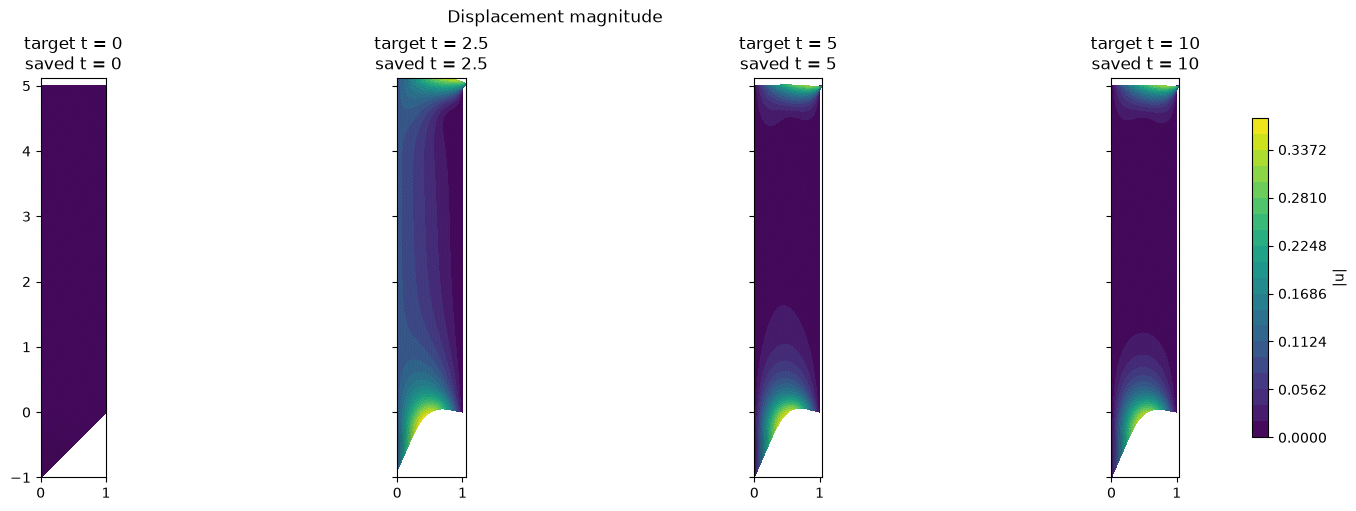

In [7]:
fig, axes = plt.subplots(1, len(sample_idx), figsize=(4 * len(sample_idx), 5), sharey=True, squeeze=False, constrained_layout=True)
axes = axes.ravel()
for ax, target, i in zip(axes, TARGET_TIMES, sample_idx):
    snap = snapshots[i]
    tri = triangulation(snap)
    umag = np.linalg.norm(snap["u"], axis=1)
    im = ax.tricontourf(tri, umag, levels=u_levels, norm=u_norm, cmap="viridis")
    ax.triplot(tri, linewidth=0.1, color="k", alpha=0.2)
    ax.set_title(snapshot_title(target, i))
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label="|u|", shrink=0.8)
fig.suptitle("Displacement magnitude")
plt.show()

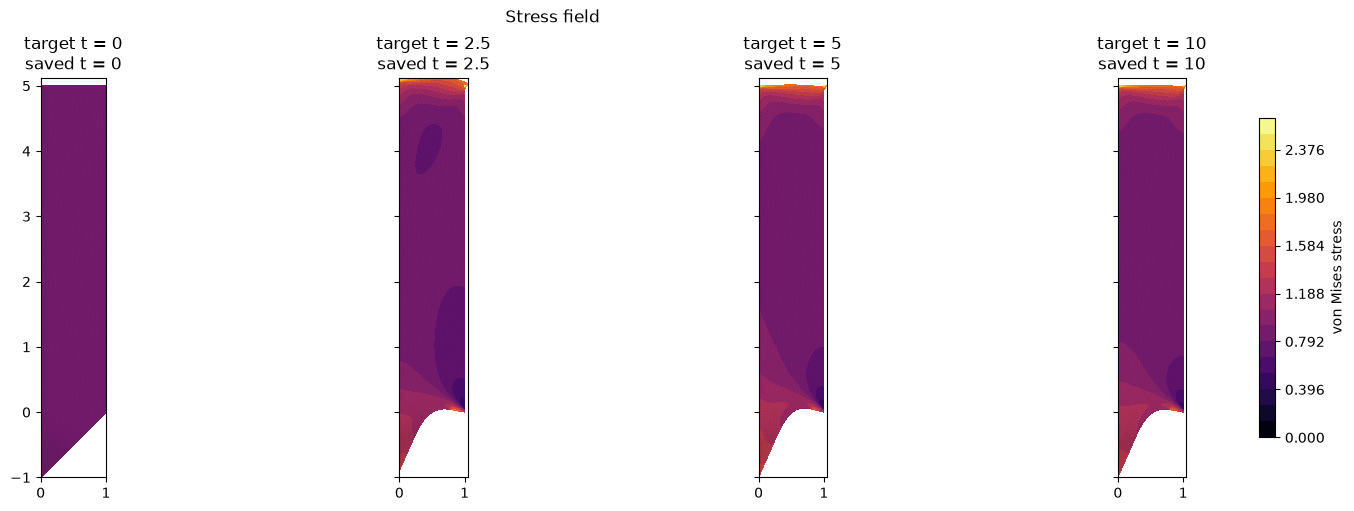

In [8]:
fig, axes = plt.subplots(1, len(sample_idx), figsize=(4 * len(sample_idx), 5), sharey=True, squeeze=False, constrained_layout=True)
axes = axes.ravel()
for ax, target, i in zip(axes, TARGET_TIMES, sample_idx):
    snap = snapshots[i]
    tri = triangulation(snap)
    im = ax.tricontourf(tri, snap["von_mises"], levels=stress_levels, norm=stress_norm, cmap="inferno")
    ax.triplot(tri, linewidth=0.1, color="k", alpha=0.2)
    ax.set_title(snapshot_title(target, i))
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label="von Mises stress", shrink=0.8)
fig.suptitle("Stress field")
plt.show()

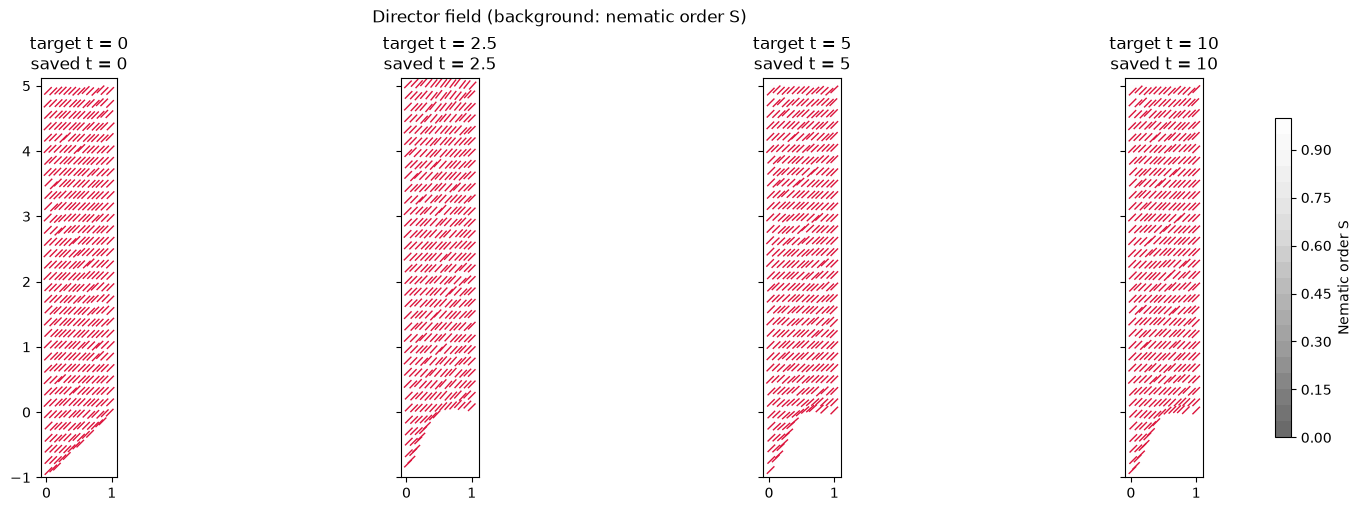

In [9]:
fig, axes = plt.subplots(1, len(sample_idx), figsize=(4 * len(sample_idx), 5), sharey=True, squeeze=False, constrained_layout=True)
axes = axes.ravel()
for ax, target, i in zip(axes, TARGET_TIMES, sample_idx):
    snap = snapshots[i]
    tri = triangulation(snap)
    im = ax.tricontourf(tri, snap["S"], levels=order_levels, norm=order_norm, cmap="Greys_r", alpha=0.6)
    x0, y0, x1, y1 = director_segments(snap)
    ax.plot(np.vstack([x0, x1]), np.vstack([y0, y1]), color="crimson", linewidth=1.0)
    ax.set_title(snapshot_title(target, i))
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label="Nematic order S", shrink=0.8)
fig.suptitle("Director field (background: nematic order S)")
plt.show()

## Four strain components at the selected time

Change `STRAIN_TARGET_TIME` in the settings cell to select another time.
Each component has its own symmetric, zero-centered scale fixed across the run.
Read the colorbars: engineering shear is twice tensor shear even when the colors look similar.

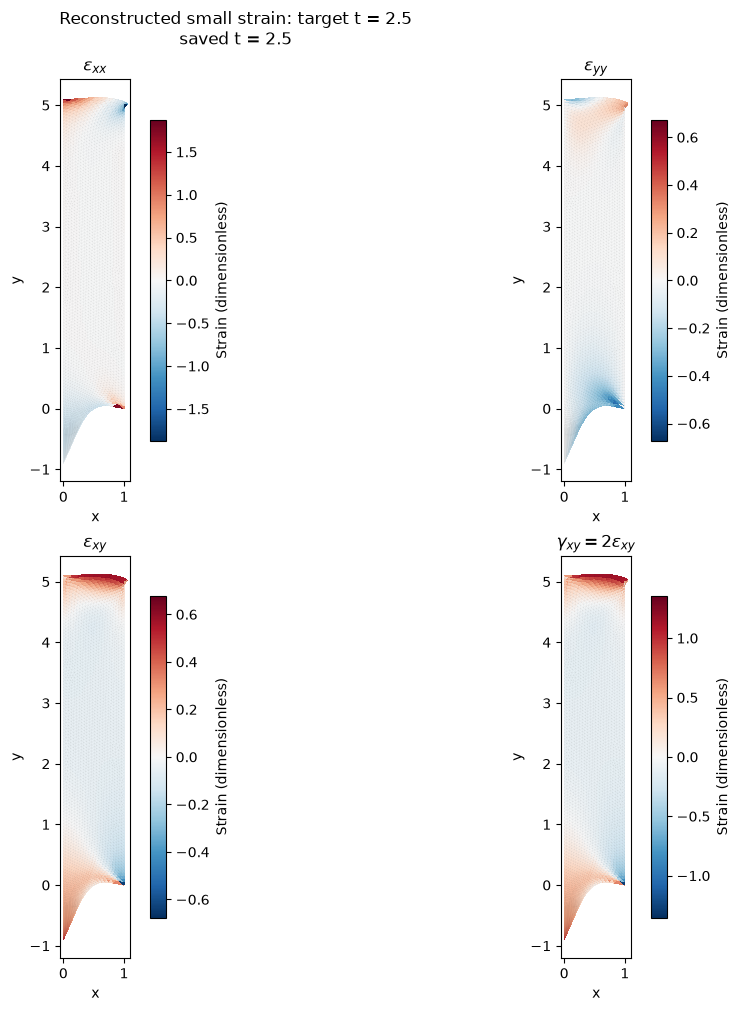

In [10]:
strain_labels = {
    "epsilon_xx": r"$\varepsilon_{xx}$",
    "epsilon_yy": r"$\varepsilon_{yy}$",
    "epsilon_xy": r"$\varepsilon_{xy}$",
    "gamma_xy": r"$\gamma_{xy}=2\varepsilon_{xy}$",
}


def plot_strain(ax, index, key):
    tri = triangulation(snapshots[index])
    im = ax.tripcolor(tri, facecolors=strain_at(index)[key], shading="flat",
                      cmap="RdBu_r", norm=strain_norms[key])
    ax.triplot(tri, linewidth=0.1, color="k", alpha=0.15)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return im


strain_index = nearest_snapshot_index(STRAIN_TARGET_TIME)
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
for ax, key in zip(axes.ravel(), strain_keys):
    im = plot_strain(ax, strain_index, key)
    ax.set_title(strain_labels[key])
    fig.colorbar(im, ax=ax, label="Strain (dimensionless)", shrink=0.8)
fig.suptitle("Reconstructed small strain: " + snapshot_title(STRAIN_TARGET_TIME, strain_index))
plt.show()

## Engineering shear strain across target times

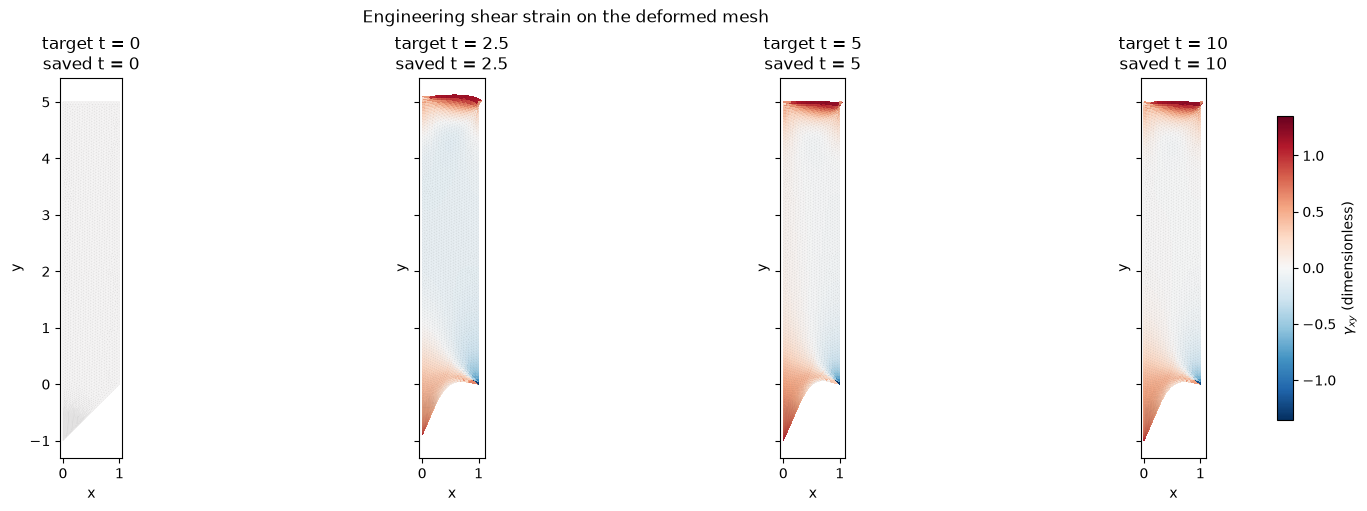

In [11]:
fig, axes = plt.subplots(1, len(sample_idx), figsize=(4 * len(sample_idx), 5),
                         sharey=True, squeeze=False, constrained_layout=True)
axes = axes.ravel()
for ax, target, index in zip(axes, TARGET_TIMES, sample_idx):
    im = plot_strain(ax, index, "gamma_xy")
    ax.set_title(snapshot_title(target, index))
fig.colorbar(im, ax=axes, label=r"$\gamma_{xy}$ (dimensionless)", shrink=0.8)
fig.suptitle("Engineering shear strain on the deformed mesh")
plt.show()

## Animations

Director and stress GIFs on the deforming mesh, using the same fixed color scales as the snapshot figures.

In [12]:
def make_director_animation(path=None, fps=10):
    path = path or os.path.join(OUTDIR, "director_animation.gif")
    fig, ax = plt.subplots(figsize=(6, 8))

    def draw(i):
        ax.clear()
        snap = snapshots[i]
        tri = triangulation(snap)
        ax.tricontourf(tri, snap["S"], levels=order_levels, norm=order_norm, cmap="Greys_r", alpha=0.6)
        x0, y0, x1, y1 = director_segments(snap)
        ax.plot(np.vstack([x0, x1]), np.vstack([y0, y1]), color="crimson", linewidth=1.0)
        ax.set_aspect("equal")
        ax.set_title(f"director field, t = {snap['t']:.2f}")
        return []

    anim = FuncAnimation(fig, draw, frames=len(snapshots), blit=False)
    anim.save(path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return path


def make_stress_animation(path=None, fps=10):
    path = path or os.path.join(OUTDIR, "stress_animation.gif")
    fig, ax = plt.subplots(figsize=(6, 8))

    def draw(i):
        ax.clear()
        snap = snapshots[i]
        tri = triangulation(snap)
        ax.tricontourf(tri, snap["von_mises"], levels=stress_levels, norm=stress_norm, cmap="inferno")
        ax.set_aspect("equal")
        ax.set_title(f"von Mises stress, t = {snap['t']:.2f}")
        return []

    anim = FuncAnimation(fig, draw, frames=len(snapshots), blit=False)
    anim.save(path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return path

In [13]:
director_path = make_director_animation()
stress_path = make_stress_animation()
print(director_path, stress_path)

output/director_animation.gif output/stress_animation.gif


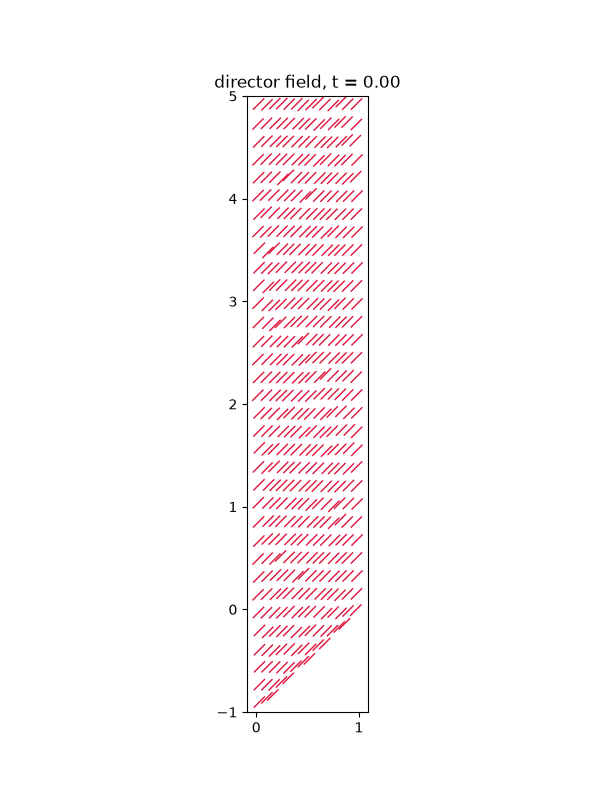

In [14]:
from IPython.display import Image
Image(filename=director_path)

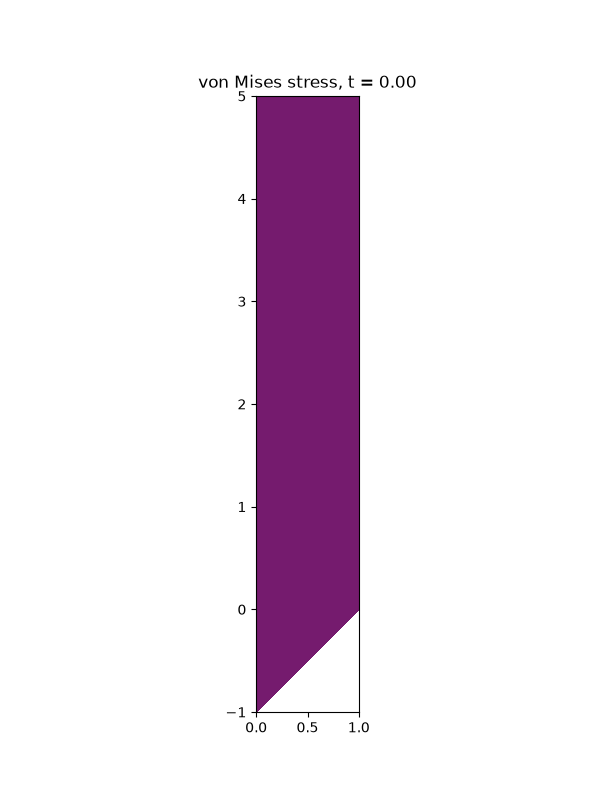

In [15]:
Image(filename=stress_path)